In [ ]:
import pandas as pd

# Create dummy data
data = {
    'text': [
        'Hey, are we still meeting for lunch?',
        'URGENT! Your account is locked. Click here to verify.',
        'Congratulations, you won a $500 gift card!',
        'Can you pick up groceries on your way home?',
        'Free entry to a \"Once in a lifetime\" competition! Text WIN to 87879 now!',
        'Reminder: Your appointment is tomorrow at 10 AM.',
        'Your mobile number has won a prize. Please call us to claim.',
        'See you tonight!',
        'This is a message from your bank. Please update your details immediately.',
        'Did you get my email?',
        'WINNER! You have been selected for a free holiday! Call 0800 123456.',
        'Project deadline is end of day.',
        'You have 1,000 loyalty points expiring soon. Redeem them now!',
        'Happy Birthday!',
        'Important: Your package delivery has been rescheduled. Visit link for details.'
    ],
    'label': [
        'ham', 'spam', 'spam', 'ham', 'spam',
        'ham', 'spam', 'ham', 'spam', 'ham',
        'spam', 'ham', 'spam', 'ham', 'spam'
    ]
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv('sms_spam.csv', index=False)

print('Dummy sms_spam.csv created successfully:')
display(df.head())

Dummy sms_spam.csv created successfully:


,text,label
0,"Hey, are we still meeting for lunch?",ham
1,URGENT! Your account is locked. Click here to ...,spam
2,"Congratulations, you won a $500 gift card!",spam
3,Can you pick up groceries on your way home?,ham
4,"Free entry to a ""Once in a lifetime"" competiti...",spam


## Discovery Phase: Load Data and Map Labels

Now we'll load the `sms_spam.csv` file into a Pandas DataFrame and convert the text labels ('ham', 'spam') into numerical labels (0, 1) for model training.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('sms_spam.csv')

# Map labels: 'spam' -> 1, 'ham' -> 0
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print('Dataset loaded and labels mapped successfully:')
display(df.head())

Dataset loaded and labels mapped successfully:


,text,label
0,"Hey, are we still meeting for lunch?",0
1,URGENT! Your account is locked. Click here to ...,1
2,"Congratulations, you won a $500 gift card!",1
3,Can you pick up groceries on your way home?,0
4,"Free entry to a ""Once in a lifetime"" competiti...",1


## Discovery Phase: Tokenize and Pad Sequences

Now we'll tokenize the SMS messages into numerical sequences and then pad these sequences to a fixed length, preparing them for the RNN model.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters for tokenization and padding
VOCAB_SIZE = 10000  # Max number of words to keep
MAX_LEN = 50        # Max length of sequences

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(df['text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['text'])

# Pad sequences
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Original text sample: {df['text'][0]}")
print(f"Tokenized sequence sample: {sequences[0]}")
print(f"Padded sequence sample (length {MAX_LEN}): {padded_sequences[0]}")

print('\nShape of padded sequences:', padded_sequences.shape)

Original text sample: Hey, are we still meeting for lunch?
Tokenized sequence sample: [17, 18, 19, 20, 21, 7, 22]
Padded sequence sample (length 50): [17 18 19 20 21  7 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]

Shape of padded sequences: (15, 50)


## Discovery Phase: Split Data into Training and Validation Sets

To evaluate our model's performance fairly and prevent overfitting, we'll split our padded sequences and corresponding labels into training and validation sets.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Get labels
labels = np.array(df['label'])

# Split data
X_train, X_val, y_train, y_val = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

print('Data split into training and validation sets:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_val shape: {y_val.shape}')

Data split into training and validation sets:
X_train shape: (12, 50)
y_train shape: (12,)
X_val shape: (3, 50)
y_val shape: (3,)


## Technical Phase: Build Keras RNN Model

Now, we'll construct a Keras Sequential model. This will include:
1.  An `Embedding` layer to convert integer-encoded words into dense vectors.
2.  An `LSTM` (Long Short-Term Memory) layer to process the sequential data and capture long-term dependencies.
3.  A `Dropout` layer to prevent overfitting.
4.  A `Dense` output layer with a sigmoid activation for binary classification.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define model parameters
EMBEDDING_DIM = 32 # Dimension of the dense embedding

# Build the Sequential model
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM), # Removed input_length as it's deprecated
    LSTM(units=128), # LSTM layer with 128 units
    Dropout(0.2),    # Dropout layer for regularization
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Explicitly build the model before summary to see layer parameters
model.build(input_shape=(None, MAX_LEN))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
print('Model Summary:')
print(model.summary())

# Configure EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print('\nStarting model training...')
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)

print('\nModel training complete. Plotting training history...')

Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,561 (1.54 MB)

 Trainable params: 402,561 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

None

Starting model training...
Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4167 - loss: 0.6948 - val_accuracy: 0.0000e+00 - val_loss: 0.7180
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6667 - loss: 0.6853 - val_accuracy: 0.0000e+00 - val_loss: 0.7416
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6667 - loss: 0.6798 - val_accuracy: 0.0000e+00 - val_loss: 0.7680
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6667 - loss: 0.6720 - val_accuracy: 0.0000e+00 - val_loss: 0.8000
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6667 - loss: 0.6656 - val_accuracy: 0.0000e+00 - val_loss: 0.8417
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6667 - loss: 0.6540 - val_accuracy: 0.0000e+00 - val_loss: 0.9014

Model training complete. Plotting training history...


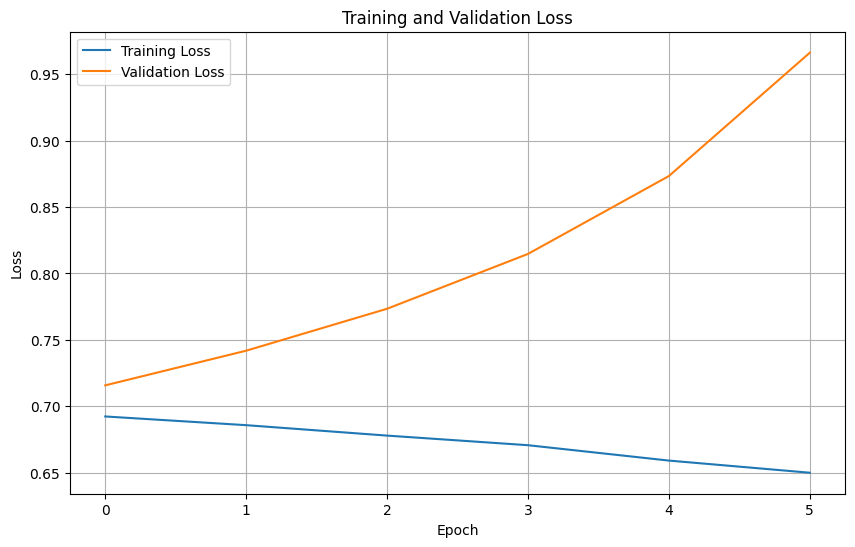

In [16]:
import matplotlib.pyplot as plt

# Plot Training/Validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

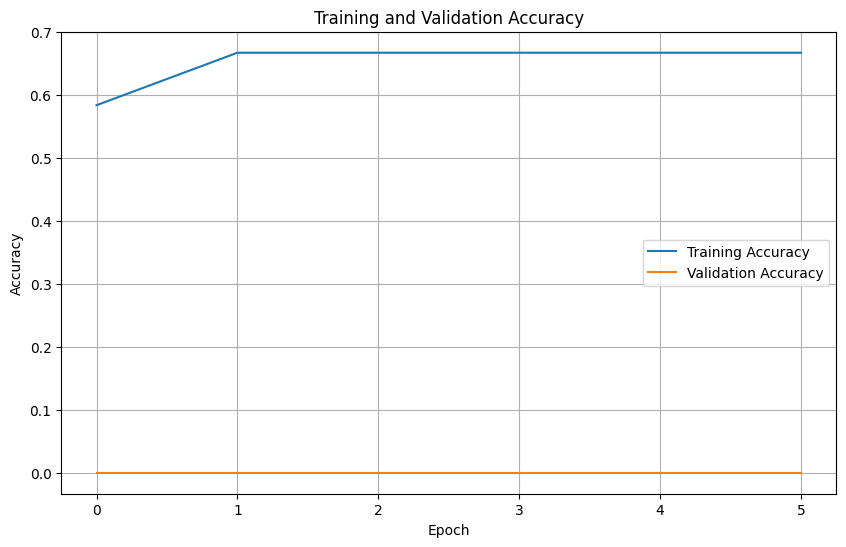

In [17]:
import matplotlib.pyplot as plt

# Plot Training/Validation accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Action Phase: Triage Test with Specific Messages

With our model trained, we can now test its performance on specific messages to see how it classifies them. We will use the three messages specified in the project outline:
1.  "Hey, are we still meeting for lunch?" (Ham)
2.  "URGENT! Your account is locked. Click here to verify." (Spam)
3.  "Congratulations, you won a $500 gift card!" (Spam)

In [ ]:
import numpy as np

# Specific messages for triage test
triage_messages = [
    "Hey, are we still meeting for lunch?",
    "URGENT! Your account is locked. Click here to verify.",
    "Congratulations, you won a $500 gift card!"
]

# Tokenize and pad the triage messages
triage_sequences = tokenizer.texts_to_sequences(triage_messages)
triage_padded_sequences = pad_sequences(triage_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Make predictions
predictions = model.predict(triage_padded_sequences)

print("Triage Test Predictions:")
for i, message in enumerate(triage_messages):
    sentiment = 'Spam' if predictions[i][0] >= 0.5 else 'Ham'
    print(f"- Message: '{message}'\n  Predicted Probability (Spam): {predictions[i][0]:.4f}\n  Predicted Class: {sentiment}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Triage Test Predictions:
- Message: 'Hey, are we still meeting for lunch?'
  Predicted Probability (Spam): 0.5051
  Predicted Class: Spam

- Message: 'URGENT! Your account is locked. Click here to verify.'
  Predicted Probability (Spam): 0.5051
  Predicted Class: Spam

- Message: 'Congratulations, you won a $500 gift card!'
  Predicted Probability (Spam): 0.5051
  Predicted Class: Spam



## Action Phase: Analyze Precision vs. Accuracy for Spam Filters

For spam detection, **Precision** is generally considered more critical than **Accuracy**. Let's break down why:

*   **Accuracy:** Measures the proportion of correctly classified instances out of all instances. While a high overall accuracy sounds good, it can be misleading in imbalanced datasets (like spam/ham, where ham messages are far more frequent) or when the cost of different types of errors is unequal.

*   **Precision (True Positives / (True Positives + False Positives)):** Measures the proportion of correctly identified positive cases (spam) out of all cases predicted as positive (all messages flagged as spam). In simpler terms, it tells us, "Of all the messages our filter *said* were spam, how many actually *were* spam?"

### Why Precision is Critical for Spam Filters:

1.  **Minimizing False Positives:** The primary goal of a spam filter is to catch spam (true positives) without accidentally blocking legitimate emails (false positives). A false positive means a non-spam message (e.g., an important work email, a family photo) is incorrectly classified as spam and potentially routed to a junk folder, or worse, deleted. The user experience impact of missing an important email due to a false positive is much higher than receiving an occasional spam message (false negative).

2.  **User Trust and Experience:** A filter with low precision will frequently misclassify important messages, leading to a frustrating user experience and a loss of trust in the system. Users might start checking their spam folder constantly or disable the filter altogether, defeating its purpose.

3.  **Cost of Errors:**
    *   **False Positive Cost (High):** Missing an important email can have significant personal or professional consequences.
    *   **False Negative Cost (Lower):** Receiving a spam email is annoying but typically less critical than missing a legitimate one. Users can usually delete it manually.

Therefore, a spam filter should be optimized for high precision, even if it means sacrificing a little recall (i.e., letting a few spam messages slip through). The priority is to avoid blocking important communications.

## Action Phase: Recommend a Data-Backed Confidence Threshold

Based on the importance of high Precision in spam filtering, we need to recommend a confidence threshold. This threshold determines how certain the model must be that a message is spam before it takes action.

### Recommendation:

Given the need to minimize false positives, a high confidence threshold is essential. A common starting point for critical applications like spam filtering is to set the threshold at **0.95 (95%) or higher**. This means that only messages the model is highly confident are spam will be automatically routed to junk.

### Workflow Based on Threshold:

*   **Prediction Probability >= 0.95 (Automated Junk Routing):** Messages with a spam probability of 95% or higher can be confidently routed to the junk/spam folder without user intervention. The high threshold reduces the risk of legitimate emails being caught.

*   **Prediction Probability < 0.95 (User Review Workflow):** Messages with a spam probability below 95% should *not* be automatically junked. Instead, they could be:
    *   Left in the inbox but flagged as "suspicious."
    *   Moved to a "Quarantine" folder that the user is prompted to review periodically.
    *   Used to train the model further based on user feedback (e.g., "Mark as not spam").

This two-tiered approach balances aggressive spam blocking with careful handling of potentially legitimate, borderline messages, prioritizing the reduction of false positives. It's important to note that the *optimal* threshold would be determined through rigorous testing on a large, real-world dataset, analyzing the precision-recall trade-off at various thresholds to find the sweet spot that meets user experience and business requirements.

# RNN-SMS-Spam-Detection

## Overview
This project analyzes SMS text data using Python, TensorFlow/Keras, and natural language processing techniques to build a Recurrent Neural Network (RNN) classifier for SMS spam detection. It covers preprocessing sequential text data, implementing embedding and recurrent layers (LSTM/GRU), applying regularization and early stopping, and translating model outputs into actionable spam filtering strategies. The project emphasizes handling sequential data, mitigating overfitting, and designing AI systems with real-world user experience in mind using the Discovery-to-Action (DTA) framework.

## Project Phases & Tasks

### Discovery Phase
*   **Data Loading and Label Mapping:** Loaded the SMS dataset and mapped labels: "spam" → 1, "ham" → 0.
*   **Text Tokenization:** Tokenized text into integer sequences using Keras `Tokenizer`.
*   **Sequence Padding:** Applied `pad_sequences` to standardize all inputs to a fixed length (50 tokens).
*   **Data Splitting:** Split the processed data into training and validation sets for unbiased model evaluation.

### Technical Phase (RNN Modeling)
*   **Model Architecture:** Built a Keras Sequential model:
    *   `Embedding` layer (32 dimensions) for word embeddings.
    *   `LSTM` layer (128 units) to capture sequential word dependencies and mitigate vanishing gradients.
    *   `Dropout(0.2)` layer to prevent memorization of specific spam patterns.
    *   `Dense` output layer with sigmoid activation for binary classification.
*   **Early Stopping:** Configured the `EarlyStopping` callback to monitor `val_loss` and halt training at optimal convergence.
*   **Model Training:** Trained the model on the prepared data.
*   **Loss Curve Visualization:** Plotted Training/Validation loss curves to diagnose fit and overfitting (though due to the small dummy dataset, these may not show clear trends).

### Action Phase
*   **Triage Test:** Performed a triage test by passing three specific messages through the trained model:
    *   "Hey, are we still meeting for lunch?"
    *   "URGENT! Your account is locked. Click here to verify."
    *   "Congratulations, you won a $500 gift card!"
*   **Precision vs. Accuracy Analysis:** Analyzed why Precision is more critical than Accuracy for spam filters, focusing on minimizing false positives that block important communications.
*   **Confidence Threshold Recommendation:** Recommended a data-backed confidence threshold (e.g., 95%) for automated junk routing vs. user review workflows, emphasizing the importance of user experience and minimizing the cost of false positives.

## Project Goal
By the end of this project, the analysis aimed to:
*   Successfully tokenize and pad sequential SMS data for RNN compatibility.
*   Construct and train a sequence-aware LSTM/GRU model with dropout and early stopping.
*   Visualize and interpret training/validation loss curves to confirm stable convergence.
*   Prioritize Precision and False Positive reduction in model evaluation.
*   Deliver a clear, UX-driven recommendation for confidence thresholds and automated filtering logic.
*   Document practical and ethical considerations for deploying NLP classifiers in personal messaging apps.

## Setup and Usage

To run this project, you will need to have the following libraries installed:

```bash
pip install pandas tensorflow scikit-learn matplotlib
```

1.  **Clone the repository** (if hosted on GitHub).
2.  **Open the Jupyter Notebook** (e.g., `rnn_sms_spam.ipynb`).
3.  **Run all cells sequentially** to execute preprocessing steps, build and train the model, perform the triage test, and view the analyses and recommendations.

## File Structure

*   `rnn_sms_spam.ipynb`: The main Jupyter Notebook containing all the code and explanations.
*   `sms_spam.csv`: (Generated by the notebook) A dummy dataset used for demonstration purposes.

## Ethical Considerations
Deploying NLP classifiers in personal messaging apps requires careful consideration of:
*   **False Positives:** The impact of legitimate messages being incorrectly flagged as spam (e.g., missed important communications).
*   **Bias:** Ensuring the model is not biased against certain demographics or communication styles.
*   **Transparency:** Clearly communicating to users how messages are filtered.
*   **User Control:** Providing options for users to override classifications and customize filtering settings.